# 02 - Feature Engineering
Gawing ML-ready ang price data natin

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)

print('Libraries loaded, MT5 connected')

Libraries loaded, MT5 connected


In [20]:
# Fetch H1 data (1 year)
symbol = 'EURUSD'
rates = mt5.copy_rates_from_pos(symbol, mt5.TIMEFRAME_H1, 0, 5000)
mt5.shutdown()

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s')
df = df.set_index('time')

print(f'{symbol}: {len(df)} H1 bars loaded')
print(f'Date range: {df.index[0]} to {df.index[-1]}')

EURUSD: 5000 H1 bars loaded
Date range: 2025-08-08 16:00:00 to 2026-05-29 23:00:00


## 1. Technical Indicators (Features)

In [21]:
# Moving Averages
df['sma_10'] = df['close'].rolling(10).mean()
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()
df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()

# Price vs MA - important for ML (% distance from MA)
df['pct_from_sma20'] = (df['close'] - df['sma_20']) / df['sma_20'] * 100
df['pct_from_sma50'] = (df['close'] - df['sma_50']) / df['sma_50'] * 100

# RSI
delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df['rsi'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df['close'].ewm(span=12, adjust=False).mean()
ema26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# Bollinger Bands
bb_mid = df['close'].rolling(20).mean()
bb_std = df['close'].rolling(20).std()
df['bb_upper'] = bb_mid + (2 * bb_std)
df['bb_lower'] = bb_mid - (2 * bb_std)
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / bb_mid * 100
df['bb_position'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

# ATR (volatility)
high_low = df['high'] - df['low']
high_close = (df['high'] - df['close'].shift()).abs()
low_close = (df['low'] - df['close'].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['atr'] = tr.rolling(14).mean()
df['atr_pct'] = df['atr'] / df['close'] * 100

print('Indicators created:', len(df.columns) - 7, 'features')

Indicators created: 17 features


## 2. Price Action Features

In [22]:
# Returns
df['return_1'] = df['close'].pct_change(1)
df['return_5'] = df['close'].pct_change(5)
df['return_10'] = df['close'].pct_change(10)

# Candle body & wick
df['body'] = abs(df['close'] - df['open'])
df['upper_wick'] = df['high'] - df[['open', 'close']].max(axis=1)
df['lower_wick'] = df[['open', 'close']].min(axis=1) - df['low']
df['body_ratio'] = df['body'] / (df['high'] - df['low']).replace(0, np.nan)

# Price range
df['range'] = df['high'] - df['low']
df['range_pct'] = df['range'] / df['close'] * 100

# Volume
df['volume_ma'] = df['tick_volume'].rolling(20).mean()
df['volume_ratio'] = df['tick_volume'] / df['volume_ma'].replace(0, np.nan)

# Lag features (previous candle values)
df['close_lag1'] = df['close'].shift(1)
df['close_lag2'] = df['close'].shift(2)
df['rsi_lag1'] = df['rsi'].shift(1)

print('Price action features created')

Price action features created


## 3. Create Target Label (Super Important!)
1 = BUY (next candle close UP)
0 = SELL (next candle close DOWN)

In [23]:
# Balanced RR — 20 TP / 20 SL (1:1)
TP_PIPS = 0.0020  # 20 pips TP
SL_PIPS = 0.0020  # 20 pips SL (1:1 RR)
LOOKAHEAD = 24

targets = []

for i in range(len(df) - LOOKAHEAD):
    entry = df['close'].iloc[i]
    tp = entry + TP_PIPS
    sl = entry - SL_PIPS

    future_highs = df['high'].iloc[i+1:i+LOOKAHEAD+1]
    future_lows = df['low'].iloc[i+1:i+LOOKAHEAD+1]

    tp_hit = (future_highs >= tp).any()
    sl_hit = (future_lows <= sl).any()

    if tp_hit and not sl_hit:
        targets.append(1)
    elif sl_hit and not tp_hit:
        targets.append(0)
    else:
        targets.append(-1)

df = df.iloc[:len(targets)].copy()
df['Target'] = targets
df = df[df['Target'] != -1]

win = (df['Target'] == 1).sum()
loss = (df['Target'] == 0).sum()
print(f'Total: {len(df)}')
print(f'WIN:  {win} | LOSS: {loss}')
print(f'Ratio: {win/(win+loss)*100:.1f}%')

Total: 3594
WIN:  1671 | LOSS: 1923
Ratio: 46.5%


In [24]:
df[['close', 'rsi', 'macd', 'atr_pct', 'Target']].tail(10)

,close,rsi,macd,atr_pct,Target
time,,,,,
2026-05-28 07:00:00,1.15912,23.546617,-0.000928,0.082144,1
2026-05-28 08:00:00,1.15986,34.425664,-0.000972,0.081537,1
2026-05-28 09:00:00,1.16096,47.290206,-0.000908,0.084474,1
2026-05-28 10:00:00,1.16111,48.868527,-0.000835,0.082556,1
2026-05-28 11:00:00,1.16150,53.083108,-0.000738,0.084005,1
2026-05-28 12:00:00,1.16125,50.032796,-0.000673,0.084699,1
2026-05-28 13:00:00,1.16031,40.048640,-0.000689,0.088893,1
2026-05-28 14:00:00,1.16165,54.863802,-0.000588,0.096906,1
2026-05-28 15:00:00,1.16358,68.004034,-0.000347,0.107611,1


## 4. Clean & Save Dataset
Remove NaN rows (from rolling calculations)

In [25]:
# Columns to keep (features lang, no lookahead)
feature_cols = [
    'sma_10', 'sma_20', 'sma_50', 'ema_12', 'ema_26',
    'pct_from_sma20', 'pct_from_sma50',
    'rsi', 'macd', 'macd_signal', 'macd_hist',
    'bb_upper', 'bb_lower', 'bb_width', 'bb_position',
    'atr', 'atr_pct',
    'return_1', 'return_5', 'return_10',
    'body', 'upper_wick', 'lower_wick', 'body_ratio',
    'range', 'range_pct',
    'tick_volume', 'volume_ma', 'volume_ratio',
    'close_lag1', 'close_lag2', 'rsi_lag1',
]

ml_data = df[feature_cols + ['Target']].dropna().copy()

print(f'Rows before dropna: {len(df)}')
print(f'Rows after dropna:  {len(ml_data)}')
print(f'Features: {len(feature_cols)}')
print(f'BUY:  {ml_data["Target"].sum():,}')
print(f'SELL: {(ml_data["Target"] == 0).sum():,}')

Rows before dropna: 3594
Rows after dropna:  3560
Features: 32
BUY:  1,653
SELL: 1,907


In [26]:
# Save to CSV for ML
ml_data.to_csv('data/EURUSD_H1_ML.csv')
print('Saved to data/EURUSD_H1_ML.csv')
print(f'Shape: {ml_data.shape}')

Saved to data/EURUSD_H1_ML.csv
Shape: (3560, 33)


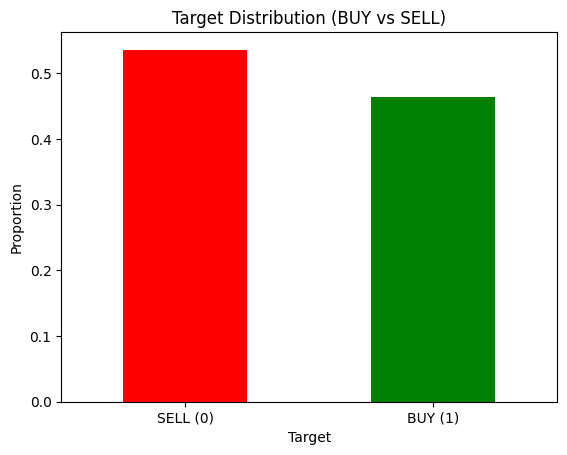

In [27]:
# Quick check: balanced ba ang data?
ml_data['Target'].value_counts(normalize=True).plot(kind='bar', 
    title='Target Distribution (BUY vs SELL)', color=['red', 'green'])
plt.xticks([0, 1], ['SELL (0)', 'BUY (1)'], rotation=0)
plt.ylabel('Proportion')
plt.show()